# Bronze Layer Exploratory Data Analysis (EDA)

Notebook ini memuat **10 Langkah EDA Komprehensif** untuk *Water Quality Dataset* (`England_dataset.csv`) dan *Station Dataset* dari MinIO Object Storage, serta analisis spasial menggunakan Rasterio untuk membaca GeoTIFF dari *local path* (`/home/jovyan/work/data/bronze/popdensity/`).

## 0. Inisialisasi Spark Session

In [22]:
import sys
import os
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType, IntegerType, StringType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("Bronze_EDA_Comprehensive") \
    .master("local[4]") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin") \
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("Spark Session Berhasil Dibuat!")

Spark Session Berhasil Dibuat!


---

# BAGIAN A: Analisis Data Kualitas Air (England_dataset.csv)

In [23]:
df_water = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("s3a://bronze/Country-Wise Data/England_dataset.csv")

### 1. Data Overview

In [24]:
print(f"Total baris: {df_water.count():,}")
print(f"Total kolom: {len(df_water.columns)}")
print("\n--- Schema ---")
df_water.printSchema()
print("\n--- Sampel Data (5 Baris) ---")
df_water.show(5, truncate=False)

Total baris: 2,129,198
Total kolom: 14

--- Schema ---
root
 |-- Country: string (nullable = true)
 |-- Area: string (nullable = true)
 |-- Waterbody Type: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Ammonia (mg/l): string (nullable = true)
 |-- Biochemical Oxygen Demand (mg/l): double (nullable = true)
 |-- Dissolved Oxygen (mg/l): double (nullable = true)
 |-- Orthophosphate (mg/l): double (nullable = true)
 |-- pH (ph units): double (nullable = true)
 |-- Temperature (cel): double (nullable = true)
 |-- Nitrogen (mg/l): double (nullable = true)
 |-- Nitrate (mg/l): double (nullable = true)
 |-- CCME_Values: double (nullable = true)
 |-- CCME_WQI: string (nullable = true)


--- Sampel Data (5 Baris) ---
+-------+----------------------------------------+--------------+----------+--------------+--------------------------------+-----------------------+---------------------+-------------+-----------------+---------------+--------------+------------------+--------+
|

### 2. Data Quality Assessment (Missing Values & Duplicates)

In [25]:
total_rows = df_water.count()
distinct_rows = df_water.distinct().count()
print(f"Jumlah Duplikasi: {total_rows - distinct_rows:,} baris\n")

# Identifikasi string kosong, 'null' string, atau NaN
null_counts = df_water.select([
    F.count(F.when(
        F.col(c).isNull() | 
        F.isnan(c) | 
        (F.trim(F.col(c)) == "") | 
        (F.lower(F.col(c)) == "null"), c
    )).alias(c) if dict(df_water.dtypes)[c] in ["double", "float"] 
    else F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == "") | (F.lower(F.col(c)) == "null"), c)).alias(c)
    for c in df_water.columns
])
print("Jumlah Missing/Anomalous Values per Kolom:")
null_counts.show(vertical=True)

Jumlah Duplikasi: 1,301 baris

Jumlah Missing/Anomalous Values per Kolom:
-RECORD 0-------------------------------
 Country                          | 0   
 Area                             | 0   
 Waterbody Type                   | 0   
 Date                             | 0   
 Ammonia (mg/l)                   | 0   
 Biochemical Oxygen Demand (mg/l) | 0   
 Dissolved Oxygen (mg/l)          | 0   
 Orthophosphate (mg/l)            | 0   
 pH (ph units)                    | 0   
 Temperature (cel)                | 0   
 Nitrogen (mg/l)                  | 0   
 Nitrate (mg/l)                   | 0   
 CCME_Values                      | 0   
 CCME_WQI                         | 0   



### 3. Descriptive Statistic

Statistik Deskriptif Kolom Numerik:
+-------+--------------------------------+-----------------------+---------------------+-------------------+-----------------+-----------------+-----------------+------------------+
|summary|Biochemical Oxygen Demand (mg/l)|Dissolved Oxygen (mg/l)|Orthophosphate (mg/l)|pH (ph units)      |Temperature (cel)|Nitrogen (mg/l)  |Nitrate (mg/l)   |CCME_Values       |
+-------+--------------------------------+-----------------------+---------------------+-------------------+-----------------+-----------------+-----------------+------------------+
|count  |2129198                         |2129198                |2129198              |2129198            |2129198          |2129198          |2129198          |2129198           |
|mean   |5.96536559171413                |10.222043947520476     |0.9072406261253888   |7.727639394043928  |11.57552514714343|6.633651157087365|5.555030822523819|80.73974401382972 |
|stddev |18.761710338700258              |1.5595101847

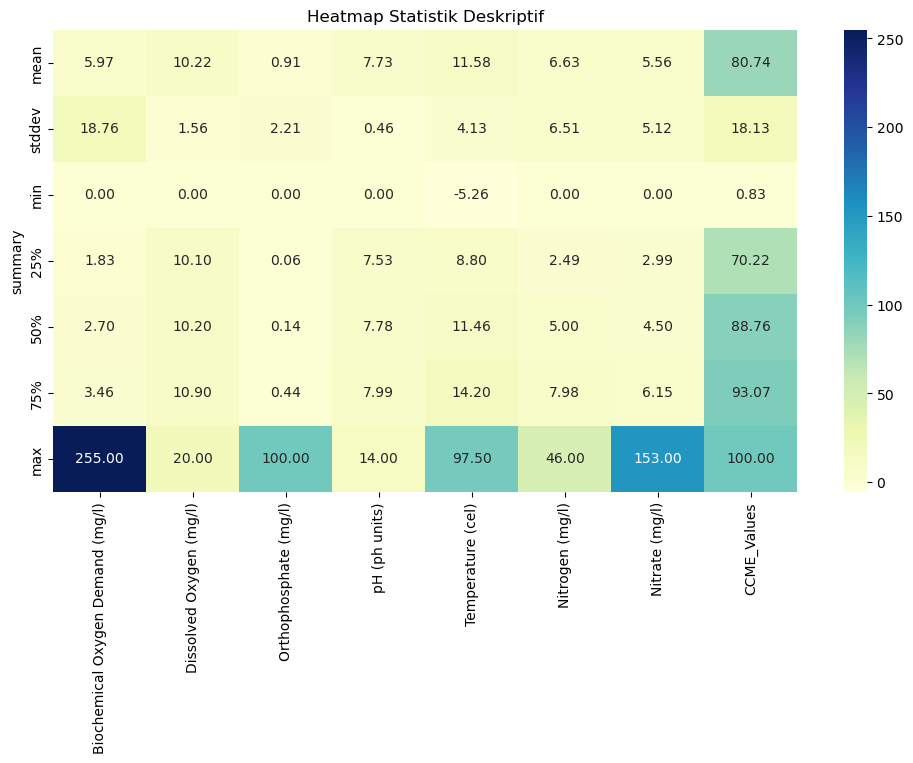

In [26]:
numeric_cols = [c for c, t in df_water.dtypes if t in ['int', 'double', 'float']]

print("Statistik Deskriptif Kolom Numerik:")
desc_df = df_water.select(numeric_cols).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
desc_df.show(truncate=False)

# Visualisasi: Heatmap dari ringkasan statistik (tanpa count)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

desc_pd = desc_df.toPandas()
desc_pd.set_index('summary', inplace=True)
# Hilangkan baris count untuk plotting yang lebih seimbang
desc_pd_numeric = desc_pd.drop('count').astype(float)

plt.figure(figsize=(12, 6))
sns.heatmap(desc_pd_numeric, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Heatmap Statistik Deskriptif")
plt.show()


### 4. Distribution Analysis

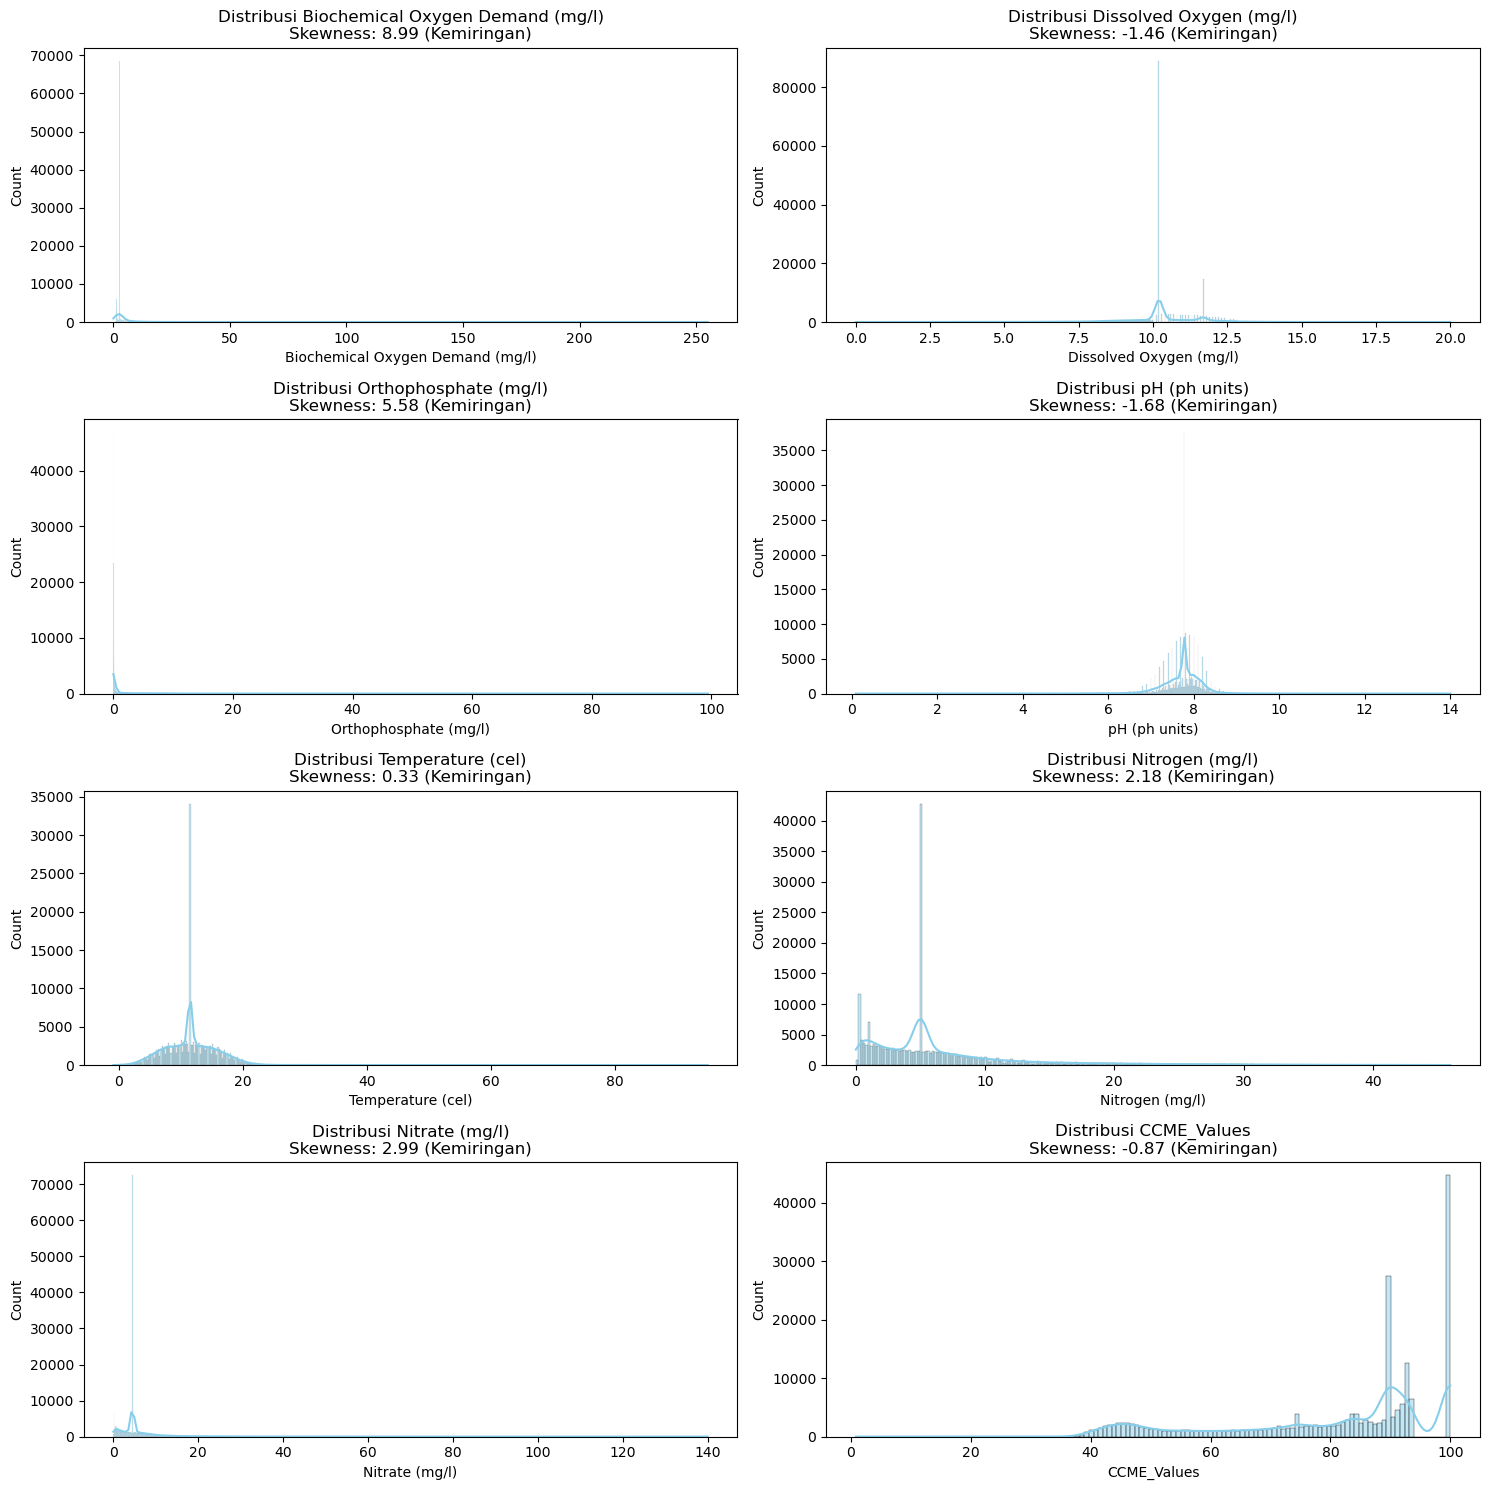

/tmp/ipykernel_110487/3642679920.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wqi_pd, x="CCME_WQI", y="count", palette="viridis")


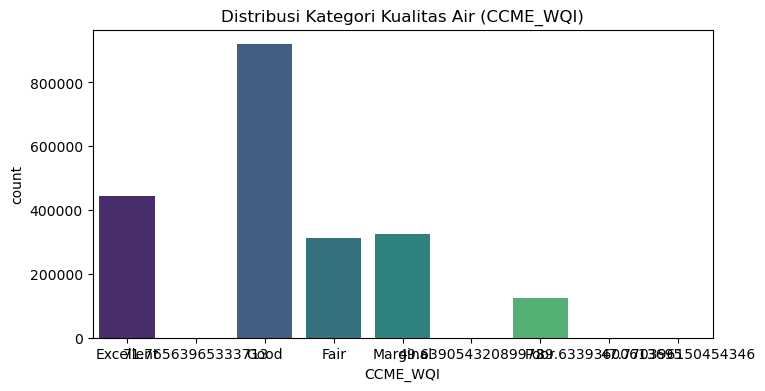

In [27]:
# Mengambil sample data untuk plotting distribusi (10% untuk performa)
sample_df = df_water.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()

# Plotting distribusi tiap kolom numerik untuk melihat skewness
fig, axes = plt.subplots(nrows=len(numeric_cols)//2 + len(numeric_cols)%2, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(sample_df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    skewness = sample_df[col].skew()
    axes[i].set_title(f"Distribusi {col}\nSkewness: {skewness:.2f} (Kemiringan)")
    
plt.tight_layout()
plt.show()

# Cek distribusi CCME_WQI (Kategorikal)
plt.figure(figsize=(8,4))
wqi_pd = df_water.groupBy("CCME_WQI").count().toPandas()
sns.barplot(data=wqi_pd, x="CCME_WQI", y="count", palette="viridis")
plt.title("Distribusi Kategori Kualitas Air (CCME_WQI)")
plt.show()


### 5. Outlier Detection

--- A. Mendeteksi Outliers dengan metode IQR dan Visualisasi Boxplot ---
[Biochemical Oxygen Demand (mg/l)] IQR Outliers: 337,547 baris
[Dissolved Oxygen (mg/l)] IQR Outliers: 383,713 baris
[Orthophosphate (mg/l)] IQR Outliers: 365,511 baris
[pH (ph units)] IQR Outliers: 86,457 baris
[Temperature (cel)] IQR Outliers: 14,657 baris
[Nitrogen (mg/l)] IQR Outliers: 183,529 baris
[Nitrate (mg/l)] IQR Outliers: 218,885 baris
[CCME_Values] IQR Outliers: 19 baris


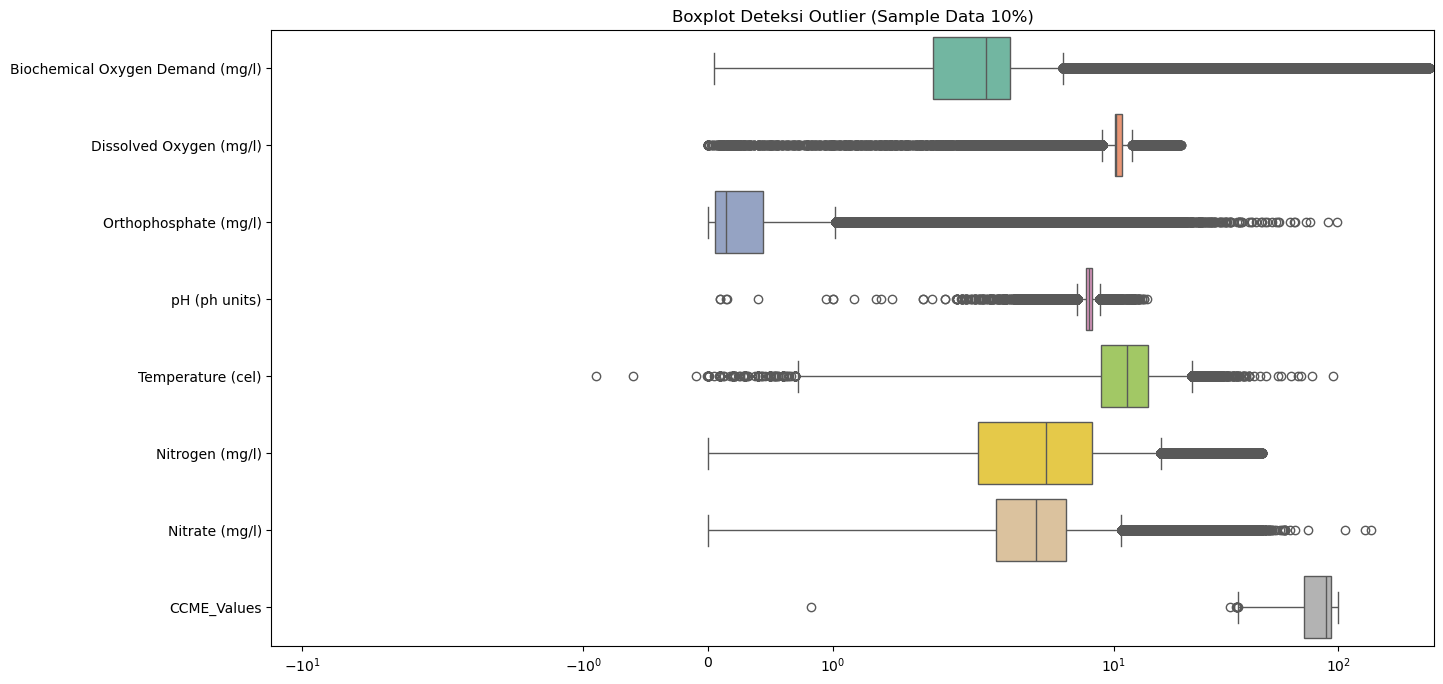


--- B. Mendeteksi Outliers dengan Z-Score (Batas 3 SD) ---
[Biochemical Oxygen Demand (mg/l)] Z-Score Outliers: 29,799 baris
[Dissolved Oxygen (mg/l)] Z-Score Outliers: 44,985 baris
[Orthophosphate (mg/l)] Z-Score Outliers: 53,679 baris
[pH (ph units)] Z-Score Outliers: 28,579 baris
[Temperature (cel)] Z-Score Outliers: 5,522 baris
[Nitrogen (mg/l)] Z-Score Outliers: 53,690 baris
[Nitrate (mg/l)] Z-Score Outliers: 51,278 baris
[CCME_Values] Z-Score Outliers: 7 baris


In [28]:
import numpy as np

print("--- A. Mendeteksi Outliers dengan metode IQR dan Visualisasi Boxplot ---")
# Menghitung quantiles
bounds = {}
for col in numeric_cols:
    quantiles = df_water.approxQuantile(col, [0.25, 0.75], 0.01)
    if len(quantiles) == 2:
        q1, q3 = quantiles
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        bounds[col] = (lower_bound, upper_bound)
        
        outliers_iqr = df_water.filter((F.col(col) < lower_bound) | (F.col(col) > upper_bound)).count()
        print(f"[{col}] IQR Outliers: {outliers_iqr:,} baris")

# Visualisasi Boxplot dari sample data
plt.figure(figsize=(15, 8))
sns.boxplot(data=sample_df[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplot Deteksi Outlier (Sample Data 10%)")
plt.xscale('symlog') # Pakai symlog agar data dengan rentang lebar tetap terlihat
plt.show()

print("\n--- B. Mendeteksi Outliers dengan Z-Score (Batas 3 SD) ---")
for col in numeric_cols:
    stats = df_water.select(F.mean(F.col(col)).alias('mean'), F.stddev(F.col(col)).alias('std')).collect()[0]
    mean, std = stats['mean'], stats['std']
    if std is not None:
        upper_bound = mean + (3 * std)
        lower_bound = mean - (3 * std)
        outliers_z = df_water.filter((F.col(col) > upper_bound) | (F.col(col) < lower_bound)).count()
        print(f"[{col}] Z-Score Outliers: {outliers_z:,} baris")


### 6. Categorical Analysis

In [29]:
cat_cols = ["Country", "Waterbody Type"]
for col in cat_cols:
    print(f"\nFrekuensi Nilai pada kolom {col}:")
    df_water.groupBy(col).count().orderBy(F.desc("count")).show(truncate=False)


Frekuensi Nilai pada kolom Country:
+-------+-------+
|Country|count  |
+-------+-------+
|England|2129198|
+-------+-------+


Frekuensi Nilai pada kolom Waterbody Type:
+--------------+-------+
|Waterbody Type|count  |
+--------------+-------+
|River         |1349570|
|Effluent      |601549 |
|Estuarine     |49375  |
|Lake          |33771  |
|Sea Water     |32061  |
|Canal         |28574  |
|Sewage        |23777  |
|Drainage      |10205  |
|Marine        |309    |
| THROCKMORTON"|6      |
| FE"          |1      |
+--------------+-------+



### 7. Relationship Analysis (Korelasi)

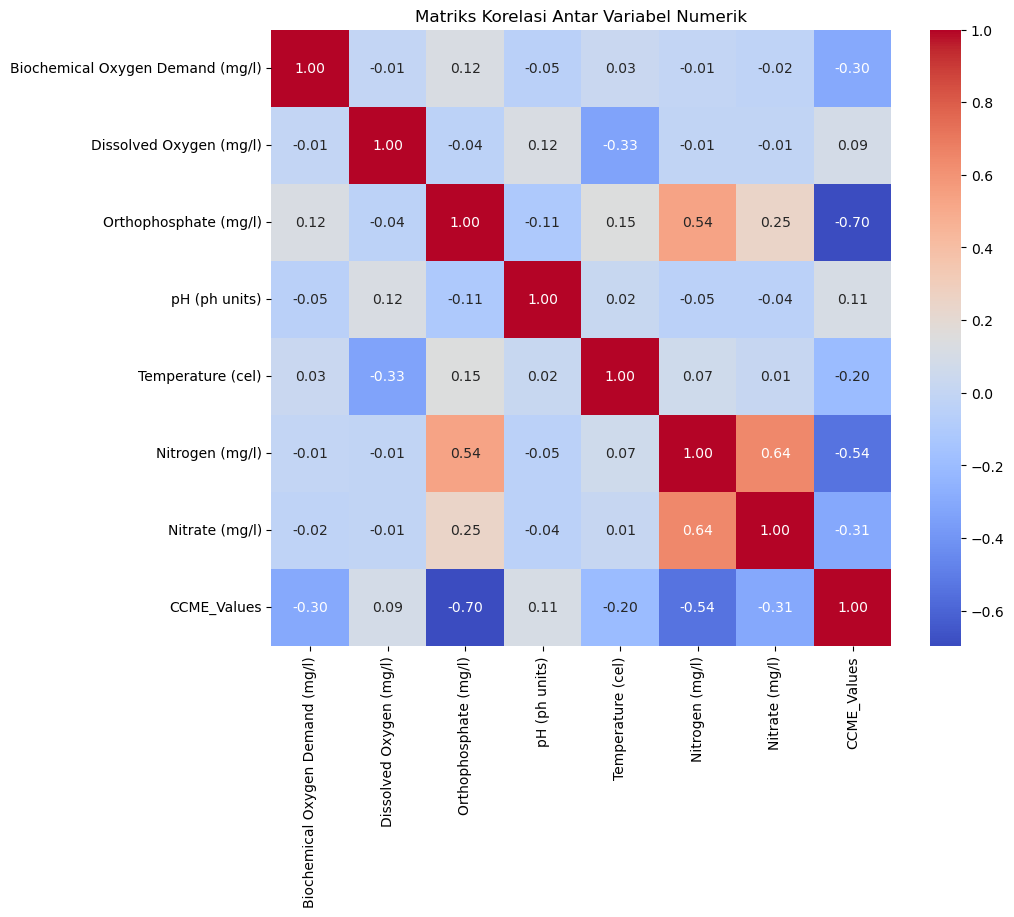

In [30]:
# Kita akan sampel data karena menghitung matriks korelasi penuh secara presisi cukup berat di Spark tanpa pandas
sample_df = df_water.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()
corr_matrix = sample_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi Antar Variabel Numerik")
plt.show()

### 8. Time-Based Analysis

Mengekstrak Tahun dari Kolom Date untuk melihat tren jumlah observasi per tahun:


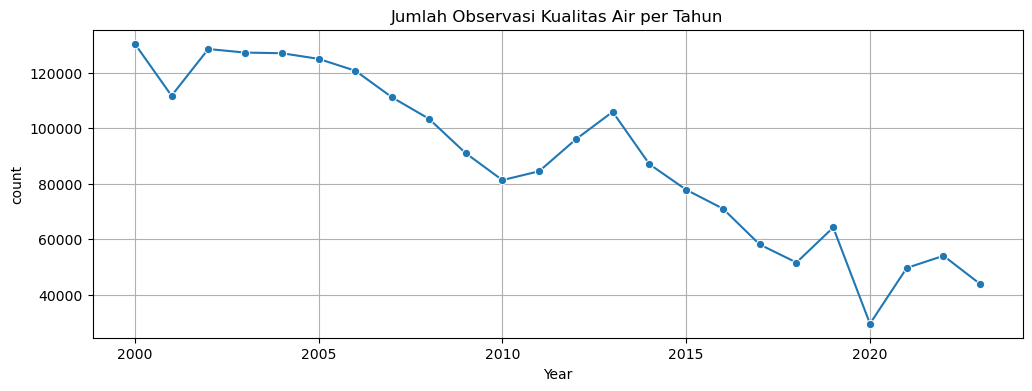

In [31]:
print("Mengekstrak Tahun dari Kolom Date untuk melihat tren jumlah observasi per tahun:")

# Format date kita mungkin dd-mm-yyyy atau dd/mm/yyyy
df_time = df_water.withColumn("ParsedDate", F.to_date(F.col("Date"), "dd-MM-yyyy"))
df_time = df_time.withColumn("Year", F.year("ParsedDate"))

yearly_counts = df_time.groupBy("Year").count().orderBy("Year").dropna().toPandas()

plt.figure(figsize=(12,4))
sns.lineplot(data=yearly_counts, x="Year", y="count", marker="o")
plt.title("Jumlah Observasi Kualitas Air per Tahun")
plt.grid(True)
plt.show()

### 9. Data Consistency Check

In [32]:
print("Mengecek Invalid Values pada setiap 14 kolom:\n")

# 1. Country (Harusnya cuma 'England' di dataset ini)
invalid_country = df_water.filter(F.col("Country") != "England").count()
print(f"1. Country selain 'England': {invalid_country:,}")

# 2. Area (Mengecek format aneh atau panjang minimal)
invalid_area = df_water.filter(F.length(F.col("Area")) < 2).count()
print(f"2. Area dengan panjang huruf < 2: {invalid_area:,}")

# 3. Waterbody Type (Cek kategori yang mungkin typo/angka)
print("3. Kategori unik Waterbody Type:")
df_water.select("Waterbody Type").distinct().show()

# 4. Date (Mengecek format regex dd-mm-yyyy)
invalid_date = df_water.filter(~F.col("Date").rlike(r"^\d{2}-\d{2}-\d{4}$")).count()
print(f"4. Date tidak sesuai format DD-MM-YYYY: {invalid_date:,}")

# Kolom 5 s/d 12 (Numerik Kualitas Air): Nilai tidak boleh bernilai sangat ekstrim negatif atau mustahil
print("\n-- Parameter Kualitas Air (Batas Nilai Ekstrim) --")
invalid_ammonia = df_water.filter((F.col("Ammonia (mg/l)").cast("double") < 0) | (F.col("Ammonia (mg/l)").cast("double") > 5000)).count()
print(f"5. Ammonia < 0 atau > 5000: {invalid_ammonia:,}")

invalid_bod = df_water.filter((F.col("Biochemical Oxygen Demand (mg/l)") < 0) | (F.col("Biochemical Oxygen Demand (mg/l)") > 5000)).count()
print(f"6. BOD < 0 atau > 5000: {invalid_bod:,}")

invalid_do = df_water.filter((F.col("Dissolved Oxygen (mg/l)") < 0) | (F.col("Dissolved Oxygen (mg/l)") > 200)).count()
print(f"7. Dissolved Oxygen < 0 atau > 200: {invalid_do:,}")

invalid_ortho = df_water.filter(F.col("Orthophosphate (mg/l)") < 0).count()
print(f"8. Orthophosphate < 0: {invalid_ortho:,}")

invalid_ph = df_water.filter((F.col("pH (ph units)") < 0) | (F.col("pH (ph units)") > 14)).count()
print(f"9. pH di luar jangkauan (0-14): {invalid_ph:,}")

invalid_temp = df_water.filter((F.col("Temperature (cel)") < -10) | (F.col("Temperature (cel)") > 60)).count()
print(f"10. Temperature < -10 atau > 60: {invalid_temp:,}")

invalid_nit = df_water.filter(F.col("Nitrogen (mg/l)") < 0).count()
print(f"11. Nitrogen < 0: {invalid_nit:,}")

invalid_nitrate = df_water.filter(F.col("Nitrate (mg/l)") < 0).count()
print(f"12. Nitrate < 0: {invalid_nitrate:,}")

print("\n-- Parameter CCME --")
invalid_ccme_val = df_water.filter((F.col("CCME_Values") < 0) | (F.col("CCME_Values") > 100)).count()
print(f"13. CCME_Values di luar (0-100): {invalid_ccme_val:,}")

valid_wqi = ["Excellent", "Good", "Fair", "Marginal", "Poor"]
invalid_wqi = df_water.filter(~F.col("CCME_WQI").isin(valid_wqi)).count()
print(f"14. CCME_WQI selain (Excellent/Good/Fair/Marginal/Poor): {invalid_wqi:,}")


Mengecek Invalid Values pada setiap 14 kolom:

1. Country selain 'England': 0
2. Area dengan panjang huruf < 2: 0
3. Kategori unik Waterbody Type:
+--------------+
|Waterbody Type|
+--------------+
|        Marine|
| THROCKMORTON"|
|          Lake|
|           FE"|
|        Sewage|
|      Effluent|
|      Drainage|
|     Estuarine|
|         River|
|         Canal|
|     Sea Water|
+--------------+

4. Date tidak sesuai format DD-MM-YYYY: 7

-- Parameter Kualitas Air (Batas Nilai Ekstrim) --
5. Ammonia < 0 atau > 5000: 0
6. BOD < 0 atau > 5000: 0
7. Dissolved Oxygen < 0 atau > 200: 0
8. Orthophosphate < 0: 0
9. pH di luar jangkauan (0-14): 0
10. Temperature < -10 atau > 60: 38
11. Nitrogen < 0: 0
12. Nitrate < 0: 0

-- Parameter CCME --
13. CCME_Values di luar (0-100): 0
14. CCME_WQI selain (Excellent/Good/Fair/Marginal/Poor): 7


### 10. Business/Domain Validation

In [33]:
print("Validasi Domain:")
print("- pH harus antara 0 hingga 14")
invalid_ph = df_water.filter((F.col("pH (ph units)") < 0) | (F.col("pH (ph units)") > 14))
print(f"pH di luar batas (0-14): {invalid_ph.count():,} baris")

print("- Dissolved Oxygen tidak boleh negatif")
invalid_do = df_water.filter(F.col("Dissolved Oxygen (mg/l)") < 0)
print(f"Dissolved Oxygen < 0: {invalid_do.count():,} baris")

Validasi Domain:
- pH harus antara 0 hingga 14
pH di luar batas (0-14): 0 baris
- Dissolved Oxygen tidak boleh negatif
Dissolved Oxygen < 0: 0 baris


---

### Kesimpulan Analisis Bagian A

**1. Data Overview & Missing Values**
* **Skala Data:** Terdapat total **2,129,198 baris** dan 14 kolom.
* **Duplikasi:** Terdapat **1,301 baris duplikat**. Ini perlu di-*drop* saat data divalidasi ke *Silver Layer*.
* **Missing Values:** Output `count` untuk nilai Null/NaN adalah **0 di seluruh 14 kolom**. Seringkali kekosongan diisi dengan *string* kosong `""` atau `"null"`/`"NA"`.

**2. Descriptive Statistic & Outliers**
* **Karakteristik Kualitas Air:** Nilai rata-rata pH adalah 7.72. Terdapat anomali seperti nilai minimal pH tercatat 0.0 dan maksimal 14.0 (ekstrim), dan Temperatur memiliki nilai maksimal **97.5 °C** yang mengindikasikan error sensor atau air buangan industri ekstrim.
* **Perbandingan IQR vs Z-Score:** Metode IQR mendeteksi outlier jauh lebih banyak (contoh BOD: 337,547 baris) dibandingkan Z-Score (29,799 baris). Data sangat bersifat *right-skew*. Pendekatan *domain threshold* (logika bisnis) lebih esensial digunakan untuk validasi di tahap Silver.

**3. Data Consistency**
Pengecekan konsistensi berhasil menemukan data kotor (*invalid*) yang wajib di-filter ke layer `rejected/`:
* **Waterbody Type Typo:** ` THROCKMORTON"` (6 baris) dan ` FE"` (1 baris). 
* **Invalid Date:** **7 baris** (tidak sesuai `DD-MM-YYYY`).
* **Invalid Temperature:** **38 baris** (< -10°C atau > 60°C).
* **Invalid CCME_WQI:** **7 baris** di luar klasifikasi yang ditentukan.


# BAGIAN B: Analisis Data Stasiun (station/*.csv)

In [49]:
# Membaca seluruh data observasi stasiun dari MinIO
# Menggunakan data aktual, namun kita akan menggunakan agregasi PySpark agar aman dari OOM (Limit RAM 4GB)
df_obs = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("s3a://bronze/station/*/*.csv")


### 1. Data Overview (Transactional Log)


In [50]:
print(f"Total baris observasi: {df_obs.count():,}")
print("\n--- Schema ---")
df_obs.printSchema()
print("\n--- Sampel Data (5 Baris) ---")
df_obs.select("id", "`samplingPoint.notation`", "phenomenonTime", "`determinand.prefLabel`", "result", "unit").show(5, truncate=False)

Total baris observasi: 60,076,180

--- Schema ---
root
 |-- id: string (nullable = true)
 |-- samplingPoint.notation: string (nullable = true)
 |-- samplingPoint.prefLabel: string (nullable = true)
 |-- samplingPoint.longitude: string (nullable = true)
 |-- samplingPoint.latitude: string (nullable = true)
 |-- samplingPoint.region: string (nullable = true)
 |-- samplingPoint.area: string (nullable = true)
 |-- samplingPoint.subArea: string (nullable = true)
 |-- samplingPoint.samplingPointStatus: string (nullable = true)
 |-- samplingPoint.samplingPointType: string (nullable = true)
 |-- phenomenonTime: string (nullable = true)
 |-- samplingPurpose: string (nullable = true)
 |-- sampleMaterialType: string (nullable = true)
 |-- determinand.notation: string (nullable = true)
 |-- determinand.prefLabel: string (nullable = true)
 |-- result: string (nullable = true)
 |-- unit: string (nullable = true)


--- Sampel Data (5 Baris) ---
+-------------------------------------------------------

### 2. Data Quality Assessment (Missing Values)


In [51]:
print("--- Missing Values Check pada Kolom Kunci ---")
cols_to_check = ["id", "`samplingPoint.notation`", "phenomenonTime", "`determinand.prefLabel`", "result"]
df_obs.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c.replace('`', '')) for c in cols_to_check
]).show()

--- Missing Values Check pada Kolom Kunci ---
+---+----------------------+--------------+---------------------+------+
| id|samplingPoint.notation|phenomenonTime|determinand.prefLabel|result|
+---+----------------------+--------------+---------------------+------+
|  0|                    95|          3557|                 3576|  6336|
+---+----------------------+--------------+---------------------+------+



### 3. Left-Censored Data Analysis (Anomali String pada Result)


In [52]:
# Mendeteksi nilai result yang mengandung karakter '<' atau '>'
censored_data = df_obs.filter(F.col("result").rlike(r"^[<>]"))
censored_count = censored_data.count()
print(f"Jumlah data tersensor (mengandung '<' atau '>'): {censored_count:,}")

print("\nContoh data tersensor:")
censored_data.select("`determinand.prefLabel`", "result", "unit").show(5, truncate=False)

# Ekstraksi angka numerik dari result untuk analisis statistik selanjutnya (Membuang tanda baca)
df_obs_clean = df_obs.withColumn(
    "result_numeric",
    F.regexp_replace(F.col("result"), r"^[<>]", "").cast("double")
)

Jumlah data tersensor (mengandung '<' atau '>'): 16,055,132

Contoh data tersensor:
+-------------------------+------+-------------------+
|determinand.prefLabel    |result|unit               |
+-------------------------+------+-------------------+
|Orthophosphate, Dissolved|<0.5  |MILLIGRAM PER LITRE|
|BOD : 5 Day ATU          |<1    |MILLIGRAM PER LITRE|
|Ammoniacal Nitrogen as N |<0.5  |MILLIGRAM PER LITRE|
|Orthophosphate, Dissolved|<0.5  |MILLIGRAM PER LITRE|
|BOD : 5 Day ATU          |<1    |MILLIGRAM PER LITRE|
+-------------------------+------+-------------------+
only showing top 5 rows



### 4. Categorical Analysis (Parameter Kualitas Air)


Top 10 Parameter (Determinand) yang paling sering diuji:


/tmp/ipykernel_110487/1321995351.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_params, y="determinand.prefLabel", x="count", palette="viridis")


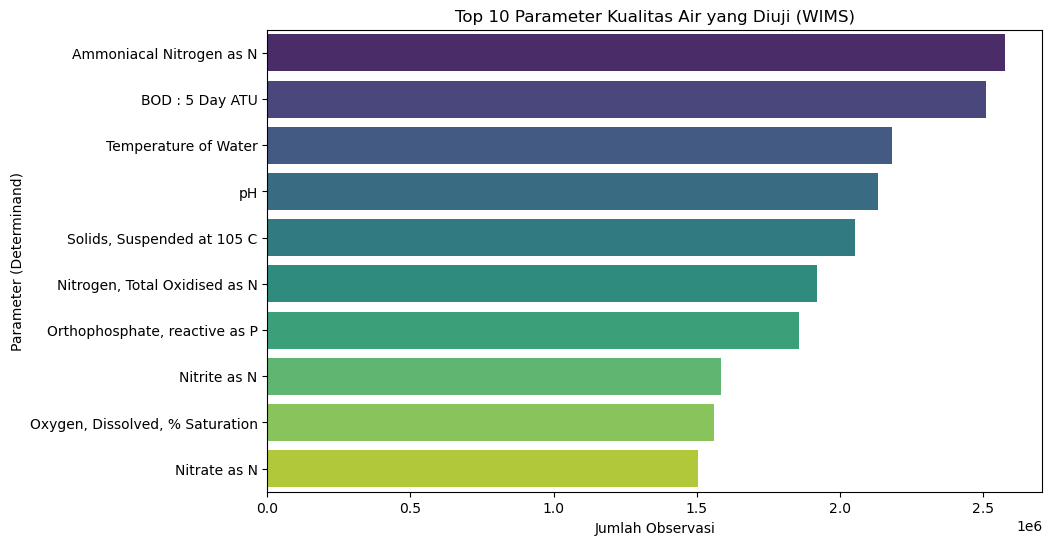

In [53]:
print("Top 10 Parameter (Determinand) yang paling sering diuji:")
# Agregasi di Spark sebelum divisualisasikan di Pandas untuk mencegah OOM
top_params = df_obs_clean.groupBy("`determinand.prefLabel`", "unit").count().orderBy(F.desc("count")).limit(10).toPandas()

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(data=top_params, y="determinand.prefLabel", x="count", palette="viridis")
plt.title("Top 10 Parameter Kualitas Air yang Diuji (WIMS)")
plt.xlabel("Jumlah Observasi")
plt.ylabel("Parameter (Determinand)")
plt.show()

### 5. Descriptive Statistic (Filter Spesifik per Parameter)


In [54]:
print("Statistik Deskriptif untuk 'Temperature of Water' & 'Ammoniacal Nitrogen as N':")
df_obs_clean.filter(F.col("`determinand.prefLabel`").isin(["Temperature of Water", "Ammoniacal Nitrogen as N"])) \
    .groupBy("`determinand.prefLabel`") \
    .agg(
        F.count("result_numeric").alias("count"),
        F.mean("result_numeric").alias("mean"),
        F.min("result_numeric").alias("min"),
        F.max("result_numeric").alias("max"),
        F.stddev("result_numeric").alias("stddev")
    ).show(truncate=False)

Statistik Deskriptif untuk 'Temperature of Water' & 'Ammoniacal Nitrogen as N':
+------------------------+-------+------------------+-----+--------+------------------+
|determinand.prefLabel   |count  |mean              |min  |max     |stddev            |
+------------------------+-------+------------------+-----+--------+------------------+
|Ammoniacal Nitrogen as N|2577456|4.346364567111952 |0.0  |124000.0|191.42323539926596|
|Temperature of Water    |2180576|11.838055760803577|-5.26|1310.0  |4.868740395972429 |
+------------------------+-------+------------------+-----+--------+------------------+



### 6. Time-Based Analysis (Tren Observasi Bulanan)


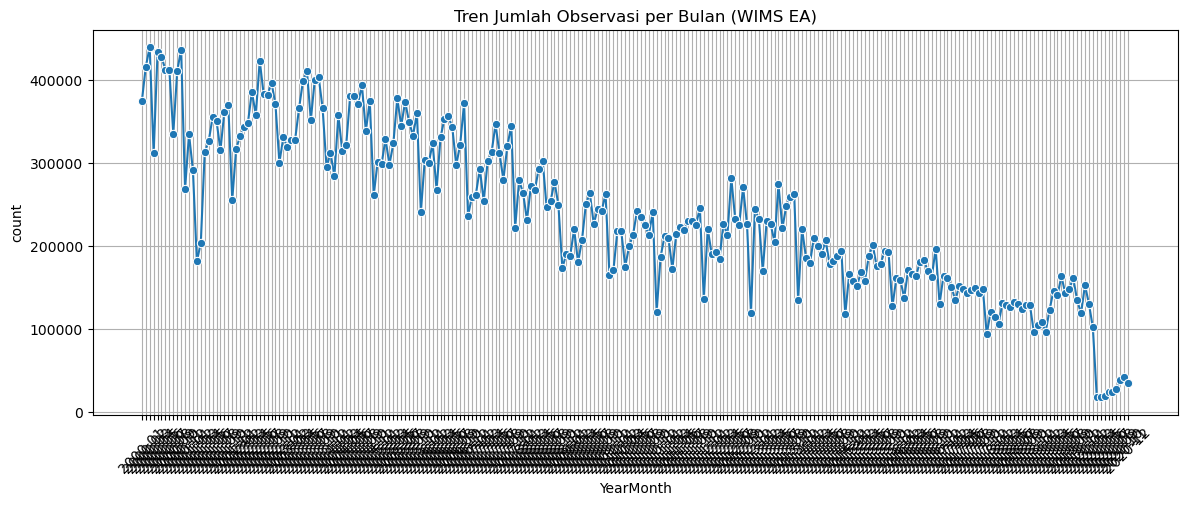

In [55]:
df_time = df_obs_clean.withColumn("ParsedDate", F.to_date(F.col("phenomenonTime")))
df_time = df_time.withColumn("YearMonth", F.date_format("ParsedDate", "yyyy-MM"))

# Menggunakan groupBy agar data yang turun ke Pandas hanya baris rekapitulasi (Ratusan baris)
monthly_counts = df_time.groupBy("YearMonth").count().orderBy("YearMonth").dropna().toPandas()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_counts, x="YearMonth", y="count", marker="o")
plt.title("Tren Jumlah Observasi per Bulan (WIMS EA)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 7. Spatial Dimension Extraction (Tabel Dimensi)


In [56]:
print("Mengekstrak Tabel Dimensi Stasiun dari Log Observasi Transaksional:")
df_stations = df_obs_clean.select(
    F.col("`samplingPoint.notation`").alias("notation"),
    F.col("`samplingPoint.prefLabel`").alias("label"),
    F.col("`samplingPoint.longitude`").cast("double").alias("longitude"),
    F.col("`samplingPoint.latitude`").cast("double").alias("latitude"),
    F.col("`samplingPoint.region`").alias("region")
).dropDuplicates(["notation"])

df_stations.cache()
print(f"Total stasiun unik ditemukan: {df_stations.count():,}")
df_stations.show(5, truncate=False)

Mengekstrak Tabel Dimensi Stasiun dari Log Observasi Transaksional:
Total stasiun unik ditemukan: 57,845
+--------------------------------------------+------------+---------+--------+--------------------------------+
|notation                                    |label       |longitude|latitude|region                          |
+--------------------------------------------+------------+---------+--------+--------------------------------+
|NULL                                        |NULL        |NULL     |NULL    |NULL                            |
| BEDS."                                     |-0.6291     |51.9472  |NULL    |ANGLIAN - CAMBS AND BEDFORDSHIRE|
| KINGS DYKE                                 | WHITTLESEY"|-0.1873  |52.5618 |Anglian                         |
| STOW LONGA                                 | KIMBOLTON  |NULL     |NULL    |NULL                            |
| significant trace: Present/Not found (1/0)"|Not found   |NULL     |NULL    |NULL                            |

### 8. Spatial Distribution (Plot Dimensi)


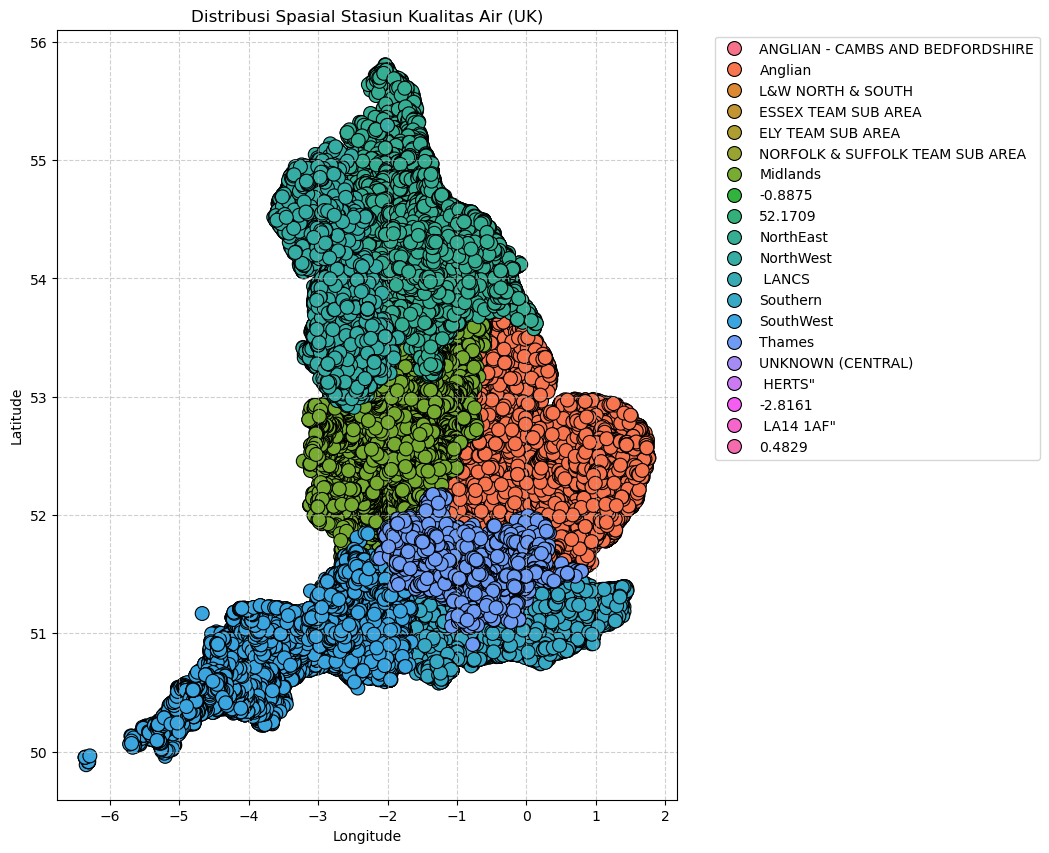

In [57]:
df_stations_pd = df_stations.toPandas()
plt.figure(figsize=(8, 10))
sns.scatterplot(data=df_stations_pd, x='longitude', y='latitude', hue='region', s=100, edgecolor='black')
plt.title("Distribusi Spasial Stasiun Kualitas Air (UK)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 9. Data Consistency Check


In [58]:
print("Mengecek relasi samplingPurpose dengan sampleMaterialType:")
df_obs_clean.groupBy("samplingPurpose", "sampleMaterialType").count().orderBy(F.desc("count")).limit(10).show(truncate=False)

print("\nMengecek anomali tanggal (phenomenonTime di masa depan):")
future_dates = df_time.filter(F.col("ParsedDate") > F.current_date()).count()
print(f"Jumlah observasi dengan tanggal di masa depan: {future_dates:,}")

Mengecek relasi samplingPurpose dengan sampleMaterialType:
+------------------------------------------------------+-----------------------------+--------+
|samplingPurpose                                       |sampleMaterialType           |count   |
+------------------------------------------------------+-----------------------------+--------+
|ENVIRONMENTAL MONITORING STATUTORY (EU DIRECTIVES)    |RIVER / RUNNING SURFACE WATER|17227477|
|COMPLIANCE AUDIT (PERMIT)                             |FINAL SEWAGE EFFLUENT        |5835306 |
|ENVIRONMENTAL MONITORING (GQA & RE ONLY)              |RIVER / RUNNING SURFACE WATER|5601551 |
|ENVIRONMENTAL MONITORING STATUTORY (EU DIRECTIVES)    |GROUNDWATER                  |4294669 |
|PLANNED INVESTIGATION (LOCAL MONITORING)              |RIVER / RUNNING SURFACE WATER|3056171 |
|ENVIRONMENTAL MONITORING STATUTORY (EU DIRECTIVES)    |SEA WATER                    |2842386 |
|MONITORING  (UK GOVT POLICY - NOT GQA OR RE)          |RIVER / RUNNING SURFA

### 10. Business/Domain Validation


In [59]:
print("Validasi Domain: Suhu air (Temperature of Water) tidak wajar ( < -10 atau > 50 Celsius )")
invalid_temp = df_obs_clean.filter(
    (F.col("`determinand.prefLabel`") == "Temperature of Water") &
    ((F.col("result_numeric") < -10) | (F.col("result_numeric") > 50))
)
print(f"Anomali suhu ekstrem: {invalid_temp.count():,} baris")

print("Validasi Format pH (0-14):")
invalid_ph = df_obs_clean.filter(
    (F.col("`determinand.prefLabel`") == "pH") &
    ((F.col("result_numeric") < 0) | (F.col("result_numeric") > 14))
)
print(f"Anomali pH: {invalid_ph.count():,} baris")

Validasi Domain: Suhu air (Temperature of Water) tidak wajar ( < -10 atau > 50 Celsius )
Anomali suhu ekstrem: 111 baris
Validasi Format pH (0-14):
Anomali pH: 0 baris


# BAGIAN C: Analisis Spasial (popdensity/*.tif - Local Access)

Membaca file: /home/jovyan/work/data/bronze/popdensity/gbr_pd_2020_1km_UNadj.tif

--- Meta Data Raster ---
CRS: EPSG:4326
Width: 1250, Height: 1321
Bands: 1
Transform: 
| 0.01, 0.00,-8.65|
| 0.00,-0.01, 60.87|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-8.65124996636112, bottom=49.857916647874134, right=1.7654166586388804, top=60.86624993717413)


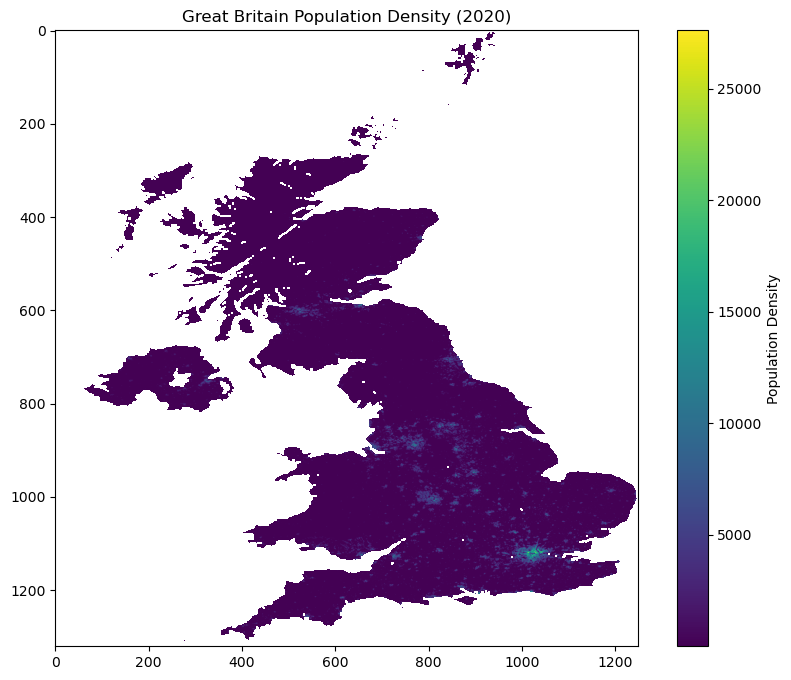

In [60]:
import rasterio
import numpy as np
from rasterio.plot import show
import matplotlib.pyplot as plt

# Mengakses dataset populasi TIF langsung dari direktori lokal proyek yang di-mount ke container
local_tif_path = "/home/jovyan/work/data/bronze/popdensity/gbr_pd_2020_1km_UNadj.tif"

try:
    print(f"Membaca file: {local_tif_path}")
    with rasterio.open(local_tif_path) as src:
        print("\n--- Meta Data Raster ---")
        print(f"CRS: {src.crs}")
        print(f"Width: {src.width}, Height: {src.height}")
        print(f"Bands: {src.count}")
        print(f"Transform: \n{src.transform}")
        print(f"Bounds: {src.bounds}")
        
        fig, ax = plt.subplots(figsize=(10, 8))
        img = src.read(1)
        img_masked = np.ma.masked_where(img < 0, img)
        
        plot = ax.imshow(img_masked, cmap='viridis')
        plt.colorbar(plot, ax=ax, label="Population Density")
        plt.title("Great Britain Population Density (2020)")
        plt.show()
        
except FileNotFoundError:
    print(f"Error: File {local_tif_path} tidak ditemukan.")
except Exception as e:
    print(f"Terjadi error: {e}")
